In [ ]:
import marimo as mo

mo.md(
    """
    # Discrete Kernel Progression

    This notebook shows how categorical GP kernels behave on mixed-input
    regression problems with two continuous features and one integer-coded
    categorical feature.

    The examples progressively change the category effect so the fitted
    models expose the intended kernel family for `GD`, `C~R`, `EHH`, `HH`,
    and `FE`. The plots use explicit category legends, not continuous
    colorbars, because category labels are nominal.
    """
)

# Discrete Kernel Progression

This notebook shows how categorical GP kernels behave on mixed-input
regression problems with two continuous features and one integer-coded
categorical feature.

The examples progressively change the category effect so the fitted
models expose the intended kernel family for `GD`, `C~R`, `EHH`, `HH`,
and `FE`. The plots use explicit category legends, not continuous
colorbars, because category labels are nominal.

In [ ]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np

from mojogp import CR, EHH, FE, GD, HH, RBF, SingleOutputGP

warnings.simplefilter("ignore")

## EHH and FE Implementation Note

MojoGP's `EHH` and `FE` currently use a positive transform of a full
hypersphere correlation with angles in `(0, pi)`. This differs from the
Saves et al. paper's EHH/FE parameterization, which constrains the
exponential variants to the nonnegative hypersphere range. In testing, the
MojoGP approach is more stable in training, so this notebook demonstrates
MojoGP's implemented kernel variants rather than a paper-reproduction
benchmark.

## What Changes Between Kernels

This notebook focuses on fitted holdout behavior rather than abstract
correlation cartoons. The examples below are designed to show the kind of
categorical structure each kernel is meant to express:

| Kernel | Categorical structure being tested |
|---|---|
| `GD` | all different levels share one mismatch strength |
| `CR` | each level has its own global mismatch strength |
| `EHH` | learned nonnegative pairwise category correlations using MojoGP's hypersphere-exponential variant |
| `HH` | signed pairwise category correlations, including opposites |
| `FE` | MojoGP's EHH-like pairwise structure plus extra per-level attenuation terms |

The RMSE heatmap later compares kernels by data pattern. It intentionally
does not claim that a more flexible kernel could never match or beat a
simpler one on one finite split.

In [ ]:
levels = 5
category_colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
]

def shared_design(
    seed=1516,
    n_train=120,
    n_test=150,
    probabilities=np.array([0.46, 0.28, 0.015, 0.21, 0.035], dtype=np.float64),
):
    rng = np.random.default_rng(seed)
    total = n_train + n_test
    X_cont = rng.uniform([-3.0, -2.2], [3.0, 2.2], size=(total, 2)).astype(
        np.float32
    )
    category_train = rng.choice(levels, size=n_train, replace=True, p=probabilities)
    category_test = np.tile(np.arange(levels), n_test // levels + 1)[:n_test]

    category_train[:levels] = np.arange(levels)
    rng.shuffle(category_train)
    rng.shuffle(category_test)
    return X_cont[:n_train], X_cont[n_train:], category_train, category_test

def common_surface(X_cont):
    x0 = X_cont[:, 0]
    x1 = X_cont[:, 1]
    return (0.25 * x1 + 0.18 * np.cos(0.65 * x0 * x1)).astype(np.float32)

def categorical_features(X_cont):
    x0 = X_cont[:, 0]
    x1 = X_cont[:, 1]
    return np.column_stack(
        [
            np.ones_like(x0),
            np.sin(1.15 * x0),
            np.cos(1.35 * x1 + 0.2 * x0),
            np.sin(0.75 * x0 - 0.45 * x1),
        ]
    ).astype(np.float32)

def evaluate_function(X_cont, category, coeffs):
    features = categorical_features(X_cont)
    per_level = np.sum(coeffs[category] * features, axis=1)
    return (common_surface(X_cont) + per_level).astype(np.float32)

In [ ]:
_x_line = np.linspace(-3.0, 3.0, 150, dtype=np.float32)
_X_curve_cont = np.column_stack([_x_line, np.zeros_like(_x_line)]).astype(np.float32)

_challenge_specs = [
    {
        "step": "1. Equidistant levels",
        "target_kernel": "GD",
        "simpler_kernel": "Continuous only",
        "story": "Every pair of distinct levels has the same categorical mismatch strength.",
        "why_simpler_fails": "A continuous-only RBF ignores the category column entirely.",
        "design_seed": 1516,
        "noise_seed": 1517,
        "noise_std": 0.12,
        "fit_iterations": 60,
        "coeffs": np.array(
            [
                [-1.25, 0.55, 0.05, 0.00],
                [-0.65, 0.55, 0.05, 0.00],
                [0.00, 0.55, 0.05, 0.00],
                [0.65, 0.55, 0.05, 0.00],
                [1.25, 0.55, 0.05, 0.00],
            ],
            dtype=np.float32,
        ),
    },
    {
        "step": "2. Isolated level",
        "target_kernel": "CR",
        "simpler_kernel": "Continuous only",
        "story": "Levels 0, 1, 2, and 4 remain related, while level 3 has a different surface.",
        "why_simpler_fails": "A continuous-only RBF ignores that level 3 follows a different categorical surface.",
        "design_seed": 1516,
        "noise_seed": 1517,
        "noise_std": 0.12,
        "fit_iterations": 60,
        "coeffs": np.array(
            [
                [-0.45, 0.75, 0.15, 0.00],
                [-0.32, 0.70, 0.17, 0.00],
                [-0.18, 0.66, 0.14, 0.00],
                [2.50, -1.50, 1.50, 1.00],
                [-0.05, 0.62, 0.16, 0.00],
            ],
            dtype=np.float32,
        ),
    },
    {
        "step": "3. Positive pair clusters",
        "target_kernel": "EHH",
        "simpler_kernel": "CR",
        "story": "Levels 0/1 and 3/4 form two positive pairwise clusters, with level 2 between them.",
        "why_simpler_fails": "CR can make levels globally close or far, but it cannot choose arbitrary close pairs.",
        "design_seed": 1516,
        "noise_seed": 1517,
        "noise_std": 0.12,
        "fit_iterations": 60,
        "coeffs": np.array(
            [
                [-1.05, 0.95, 0.10, 0.10],
                [-0.92, 0.86, 0.13, 0.05],
                [0.05, 0.38, 0.55, 0.10],
                [0.82, 0.08, 0.88, 0.20],
                [0.98, 0.10, 0.80, 0.24],
            ],
            dtype=np.float32,
        ),
    },
    {
        "step": "4. Signed opposites",
        "target_kernel": "HH",
        "simpler_kernel": "Continuous only",
        "story": "Some levels are mirror images, so signed pairwise relationships are meaningful.",
        "why_simpler_fails": "A continuous-only RBF cannot represent mirror-image category surfaces.",
        "design_seed": 6007,
        "noise_seed": 6008,
        "noise_std": 0.06,
        "fit_iterations": 90,
        "probabilities": np.full(levels, 1.0 / levels, dtype=np.float64),
        "coeffs": np.array(
            [
                [0.00, 1.7247156, 0.15, 0.00],
                [0.00, 1.3797724, 0.10, 0.00],
                [0.00, -1.7247156, -0.15, 0.00],
                [0.00, 0.05, 0.50054246, 0.46950713],
                [0.00, -0.05, -0.50054246, -0.46950713],
            ],
            dtype=np.float32,
        ),
    },
    {
        "step": "5. Pair clusters + attenuation",
        "target_kernel": "FE",
        "simpler_kernel": "CR",
        "story": "There are positive pairwise clusters plus per-level attenuation effects.",
        "why_simpler_fails": "CR learns per-level distances, but it cannot also learn arbitrary positive pairwise clusters.",
        "design_seed": 1516,
        "noise_seed": 1517,
        "noise_std": 0.12,
        "fit_iterations": 60,
        "coeffs": np.array(
            [
                [-0.90, 0.88, 0.12, 0.06],
                [-0.78, 0.82, 0.16, 0.05],
                [0.02, 0.38, 0.64, 0.18],
                [0.78, 0.10, 0.90, 0.24],
                [1.45, 0.08, 0.15, 1.05],
            ],
            dtype=np.float32,
        ),
    },
]

challenges = []
for _spec in _challenge_specs:
    _coeffs = _spec["coeffs"]
    _X_cont_train, _X_cont_test, _category_train, _category_test = shared_design(
        seed=_spec["design_seed"],
        probabilities=_spec.get(
            "probabilities",
            np.array([0.46, 0.28, 0.015, 0.21, 0.035], dtype=np.float64),
        ),
    )
    _rng = np.random.default_rng(_spec["noise_seed"])
    _f_train = evaluate_function(_X_cont_train, _category_train, _coeffs)
    _f_test = evaluate_function(_X_cont_test, _category_test, _coeffs)
    _y_train = (
        _f_train + _spec["noise_std"] * _rng.standard_normal(_f_train.shape)
    ).astype(np.float32)
    _X_train = np.column_stack(
        [_X_cont_train, _category_train.astype(np.float32)]
    ).astype(np.float32)
    _X_test = np.column_stack(
        [_X_cont_test, _category_test.astype(np.float32)]
    ).astype(np.float32)

    _curve_truth = []
    _curve_X = []
    for _cat in range(levels):
        _cat_column = np.full(_x_line.shape, _cat, dtype=np.float32)
        _curve_X_cat = np.column_stack([_X_curve_cont, _cat_column]).astype(
            np.float32
        )
        _curve_X.append(_curve_X_cat)
        _curve_truth.append(
            evaluate_function(
                _X_curve_cont,
                np.full(_x_line.shape, _cat, dtype=np.int64),
                _coeffs,
            )
        )

    _challenge = dict(_spec)
    _challenge.update(
        {
            "X_train": _X_train,
            "y_train": _y_train,
            "X_test": _X_test,
            "f_test": _f_test,
            "curve_X": np.vstack(_curve_X).astype(np.float32),
            "curve_truth": np.vstack(_curve_truth).astype(np.float32),
            "x_line": _x_line,
        }
    )
    challenges.append(_challenge)

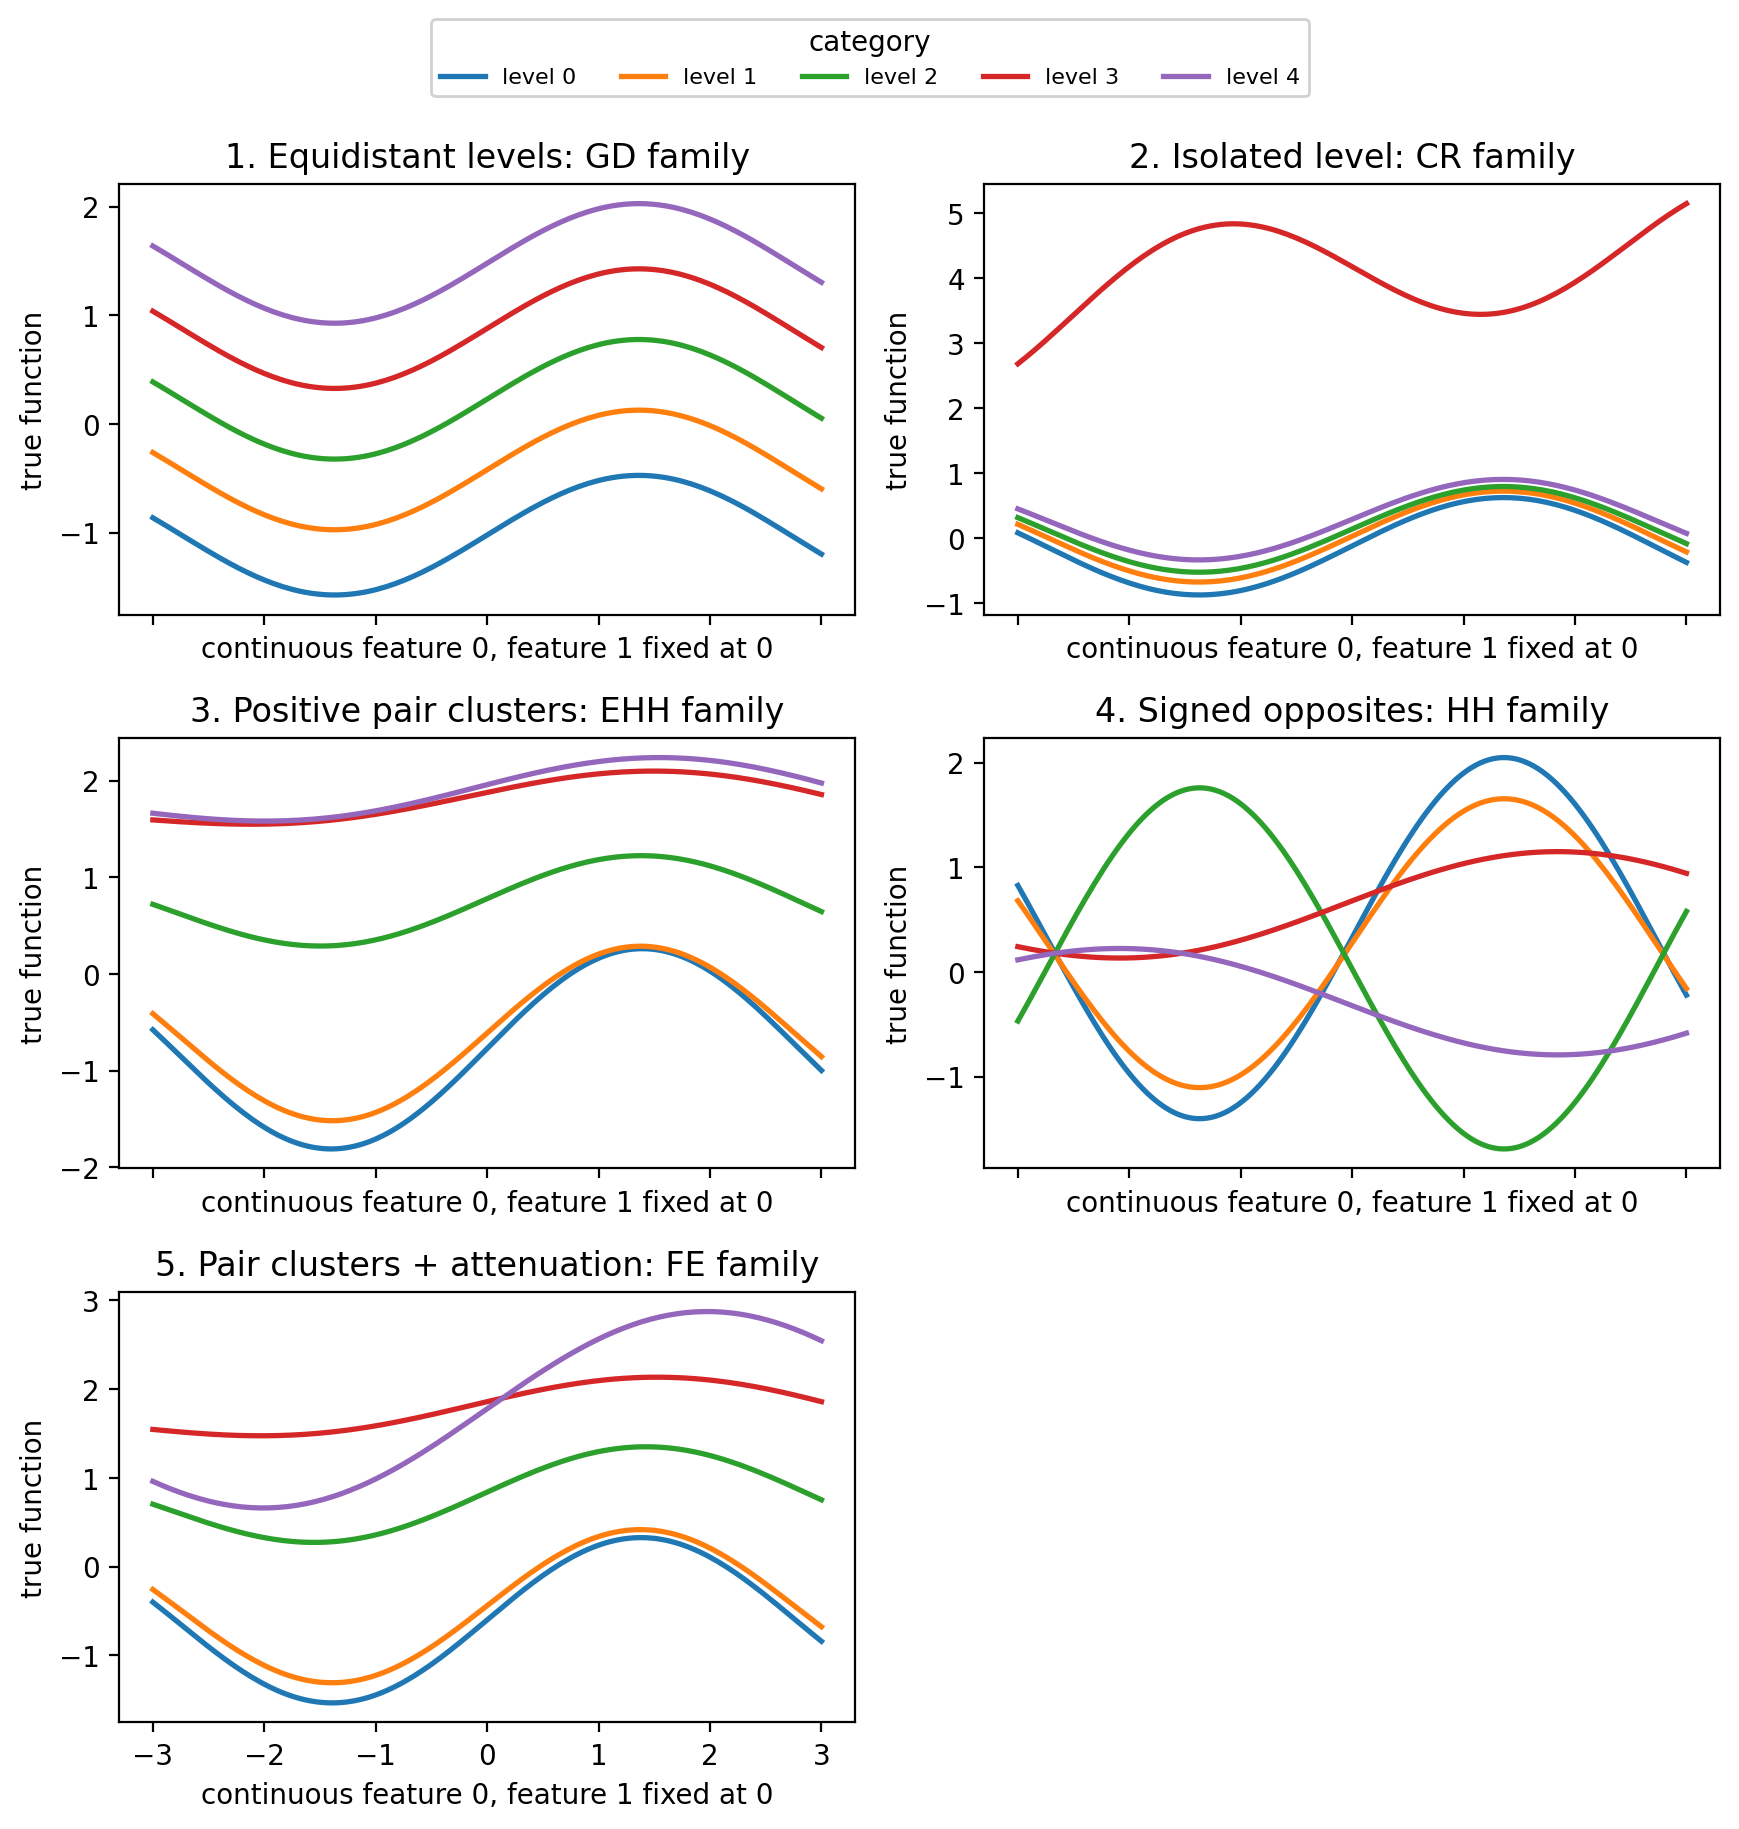

Data Generating Process 
 Every panel uses the same continuous formula family. The category
coefficient table changes by row, and the signed HH row uses a
balanced category split so the negative relationships have enough
evidence to be learned. The legend is discrete because levels 0 
through 4 are labels, not a continuous numeric axis.
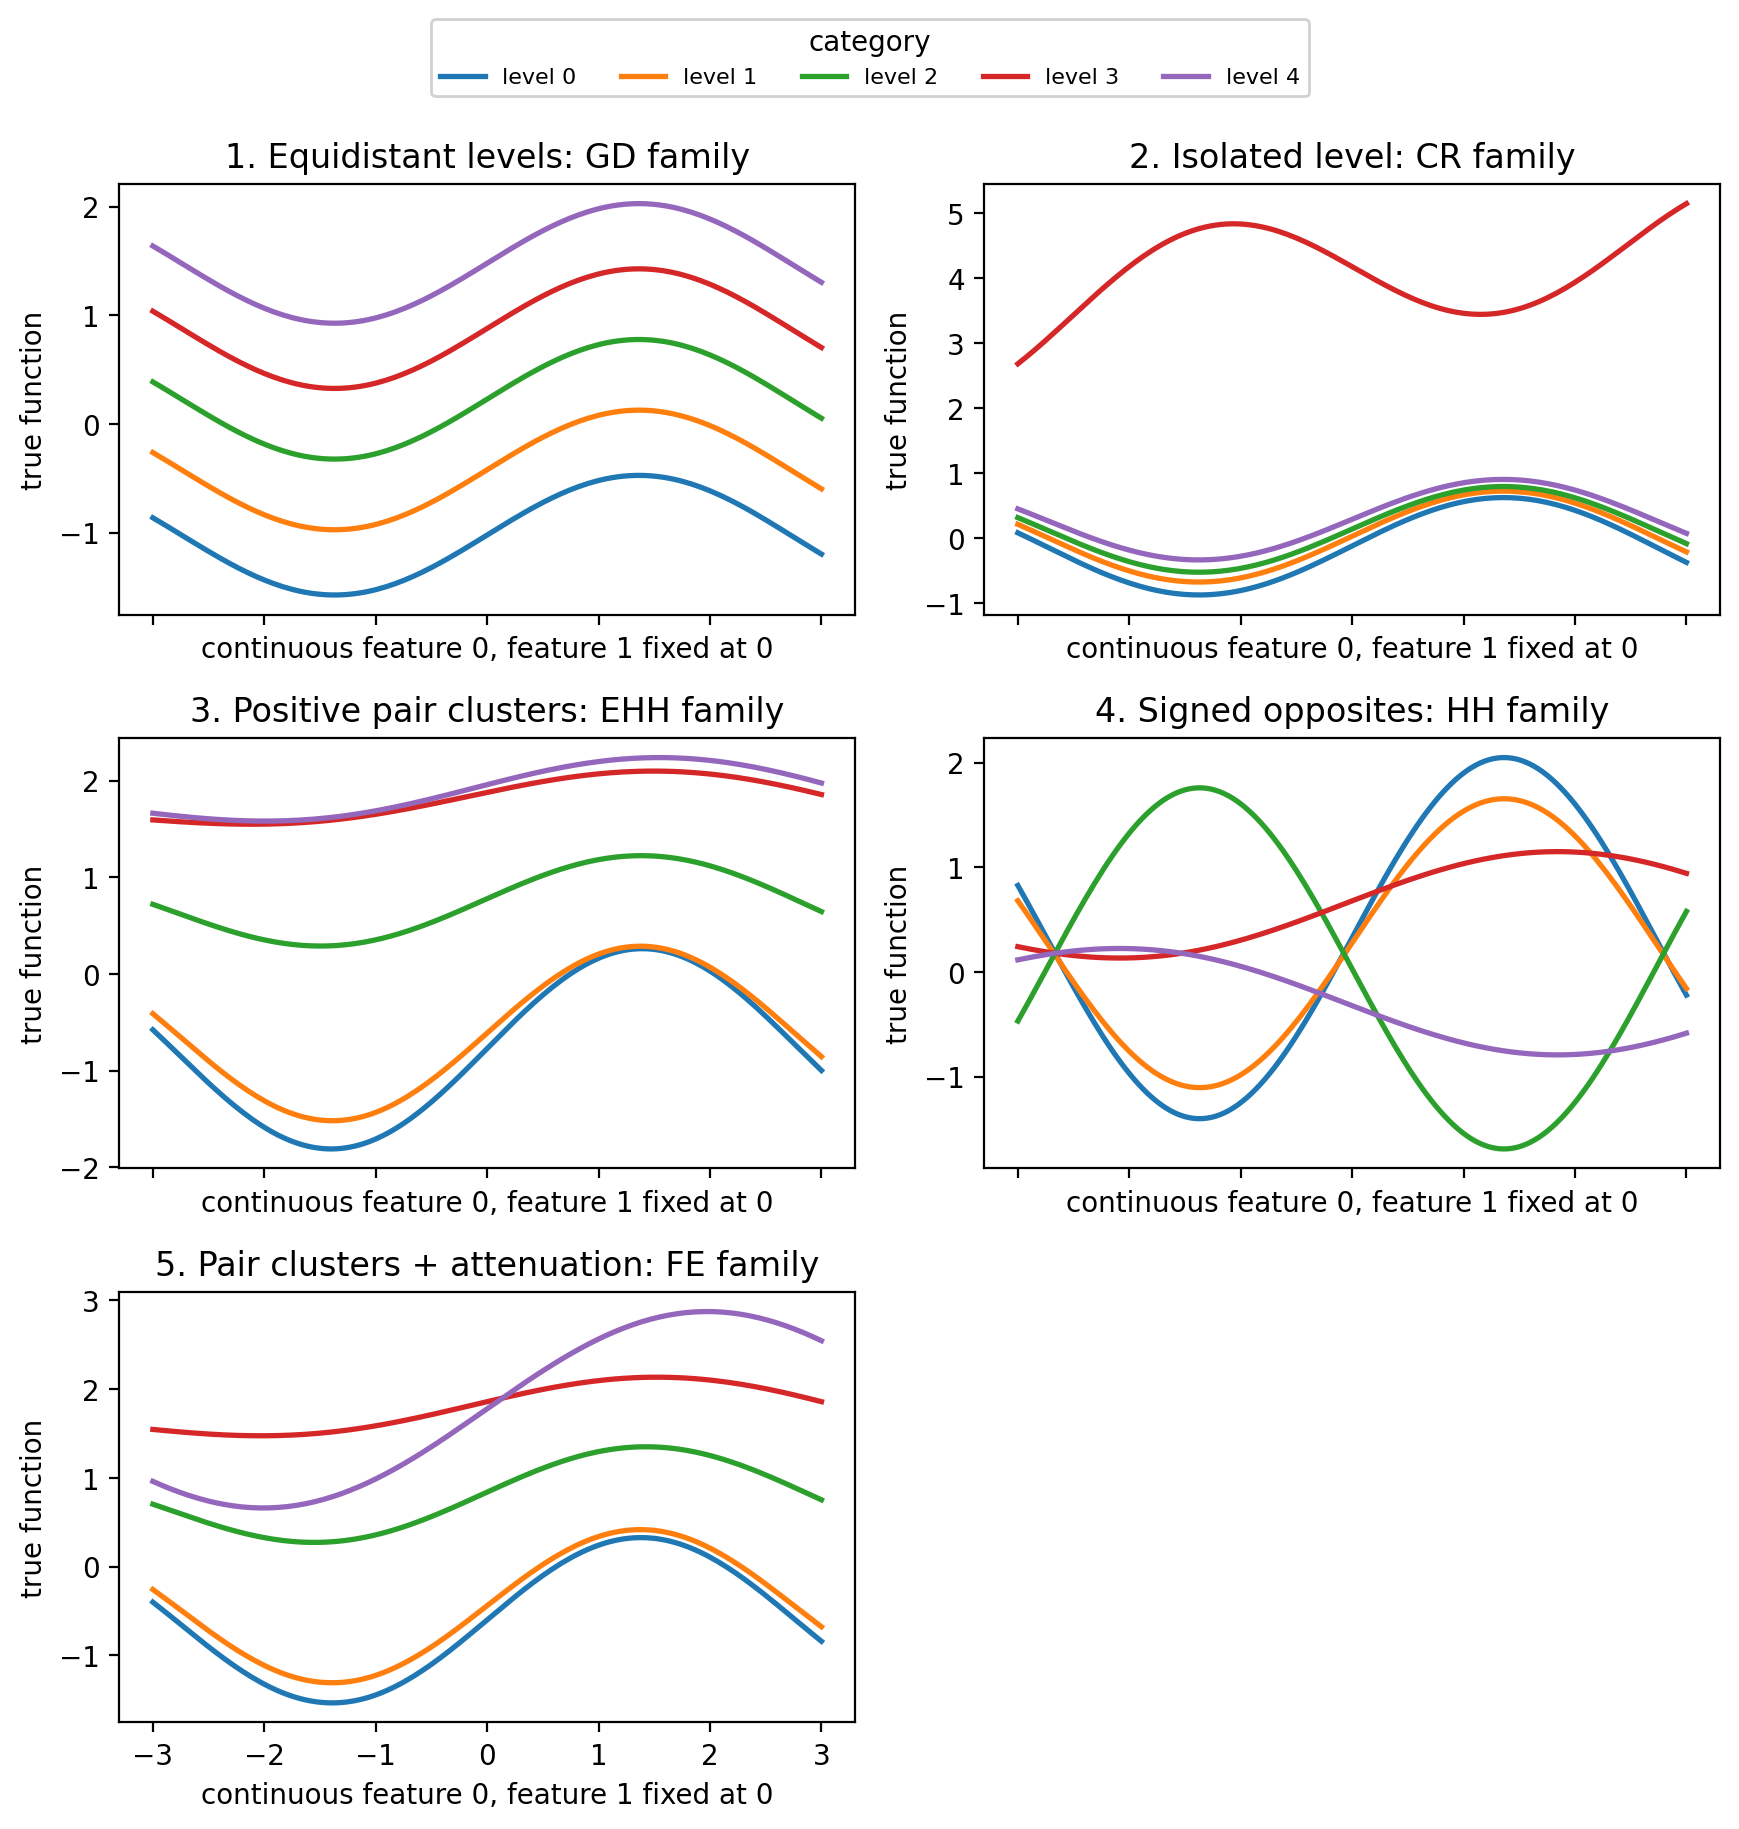

In [ ]:
from matplotlib.lines import Line2D as _Line2D

_fig, _axes = plt.subplots(3, 2, figsize=(8.8, 9.2), sharex=True, sharey=False)
_flat_axes = _axes.ravel()
for _ax, _challenge in zip(_flat_axes, challenges):
    _x_line = _challenge["x_line"]
    for _cat, _color in enumerate(category_colors):
        _ax.plot(
            _x_line,
            _challenge["curve_truth"][_cat],
            color=_color,
            linewidth=1.9,
        )
    _ax.set_title(f"{_challenge['step']}: {_challenge['target_kernel']} family")
    _ax.set_xlabel("continuous feature 0, feature 1 fixed at 0")
    _ax.set_ylabel("true function")
_flat_axes[-1].axis("off")
_legend_handles = [
    _Line2D([0], [0], color=_color, linewidth=1.9, label=f"level {_cat}")
    for _cat, _color in enumerate(category_colors)
]
_fig.legend(
    handles=_legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.995),
    ncol=len(category_colors),
    title="category",
    fontsize=8,
    framealpha=0.9,
)
_fig.tight_layout(rect=(0, 0, 1, 0.94))

mo.vstack(
    [
        mo.md(
            """
            ## Data Generating Process

            Every panel uses the same continuous formula family. The category
            coefficient table changes by row, and the signed `HH` row uses a
            balanced category split so the negative relationships have enough
            evidence to be learned. The legend is discrete because levels `0`
            through `4` are labels, not a continuous numeric axis.
            """
        ),
        mo.mpl.interactive(_fig),
    ]
)

In [ ]:
_kernel_builders = {
    "GD": GD,
    "CR": CR,
    "EHH": EHH,
    "HH": HH,
    "FE": FE,
}
model_codes = ["Continuous only", "GD", "CR", "EHH", "HH", "FE"]

_fit_settings = {
    "method": "materialized",
    "max_iterations": 60,
    "learning_rate": 0.03,
    "verbose": False,
}

def rmse(pred, truth):
    return float(np.sqrt(np.mean((pred - truth) ** 2)))

def build_kernel(kernel_code):
    if kernel_code == "Continuous only":
        return RBF(active_dims=[0, 1])
    return RBF(active_dims=[0, 1]) * _kernel_builders[kernel_code](
        levels=levels,
        active_dims=[2],
    )

def fit_one(challenge, kernel_code):
    start = time.perf_counter()
    gp = SingleOutputGP(build_kernel(kernel_code))
    _settings = dict(_fit_settings)
    _settings["max_iterations"] = challenge["fit_iterations"]
    result = gp.fit(challenge["X_train"], challenge["y_train"], **_settings)
    mean = gp.predict(
        challenge["X_test"],
        variance_method="mean_only",
    ).mean

    shuffled_rmse = None
    if kernel_code != "Continuous only":
        shuffled_X = challenge["X_test"].copy()
        rng = np.random.default_rng(9000 + len(challenge["step"]) + len(kernel_code))
        shuffled_X[:, 2] = rng.permutation(shuffled_X[:, 2])
        shuffled_mean = gp.predict(
            shuffled_X,
            variance_method="mean_only",
        ).mean
        shuffled_rmse = rmse(shuffled_mean, challenge["f_test"])

    return {
        "step": challenge["step"],
        "kernel": kernel_code,
        "rmse": rmse(mean, challenge["f_test"]),
        "shuffled_rmse": shuffled_rmse,
        "nll": float(result.nll),
        "seconds": time.perf_counter() - start,
        "mean": mean,
    }

progression_results = []
for _challenge in challenges:
    for _kernel_code in model_codes:
        progression_results.append(fit_one(_challenge, _kernel_code))

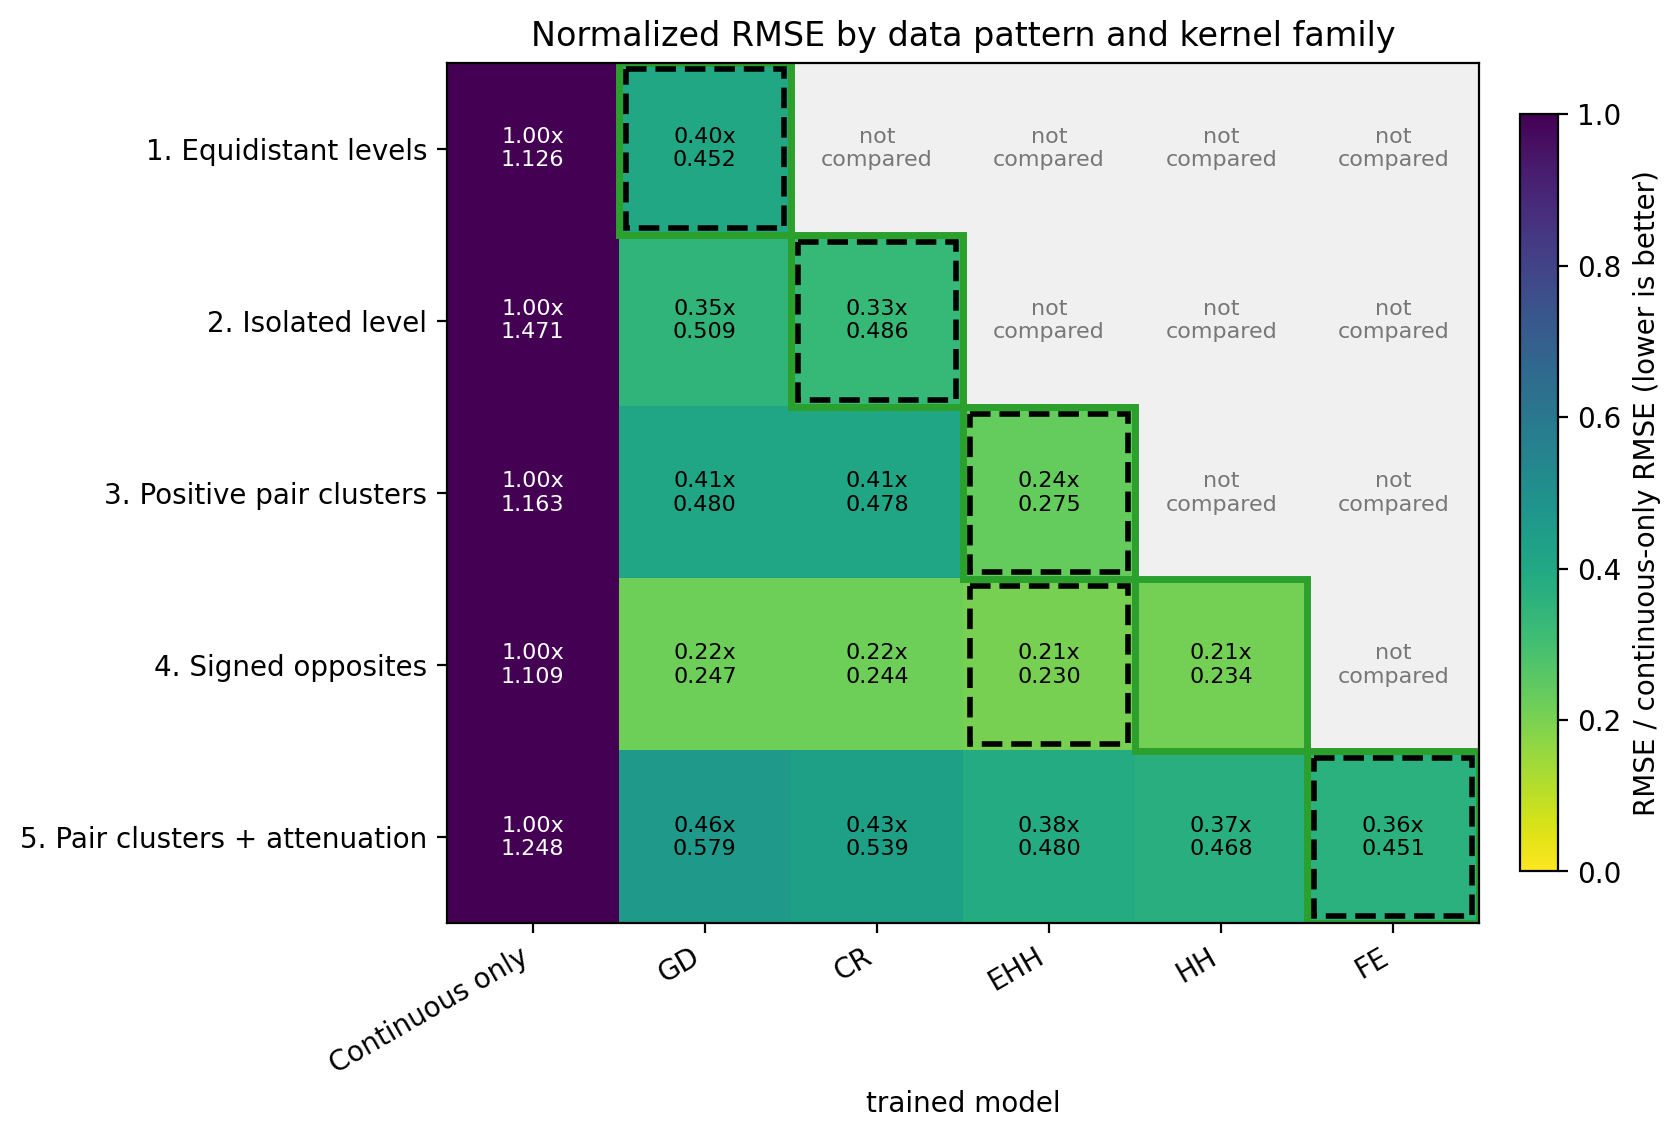

Fitted Model Progression 
 Each row fits all five categorical kernels plus the continuous
baseline, but the heatmap is shown as a decision ladder. A row
displays only the baseline and the kernel families introduced up
to that step; later, more flexible families are blanked out rather
than treated as automatic winners for simpler patterns. 
 The numbers are RMSE / continuous-only RMSE , with the absolute
RMSE underneath. Values below 1.00x improve on the continuous
baseline. The green outline marks the intended kernel family for
that synthetic pattern; the black dashed outline marks the best
displayed model in that row.
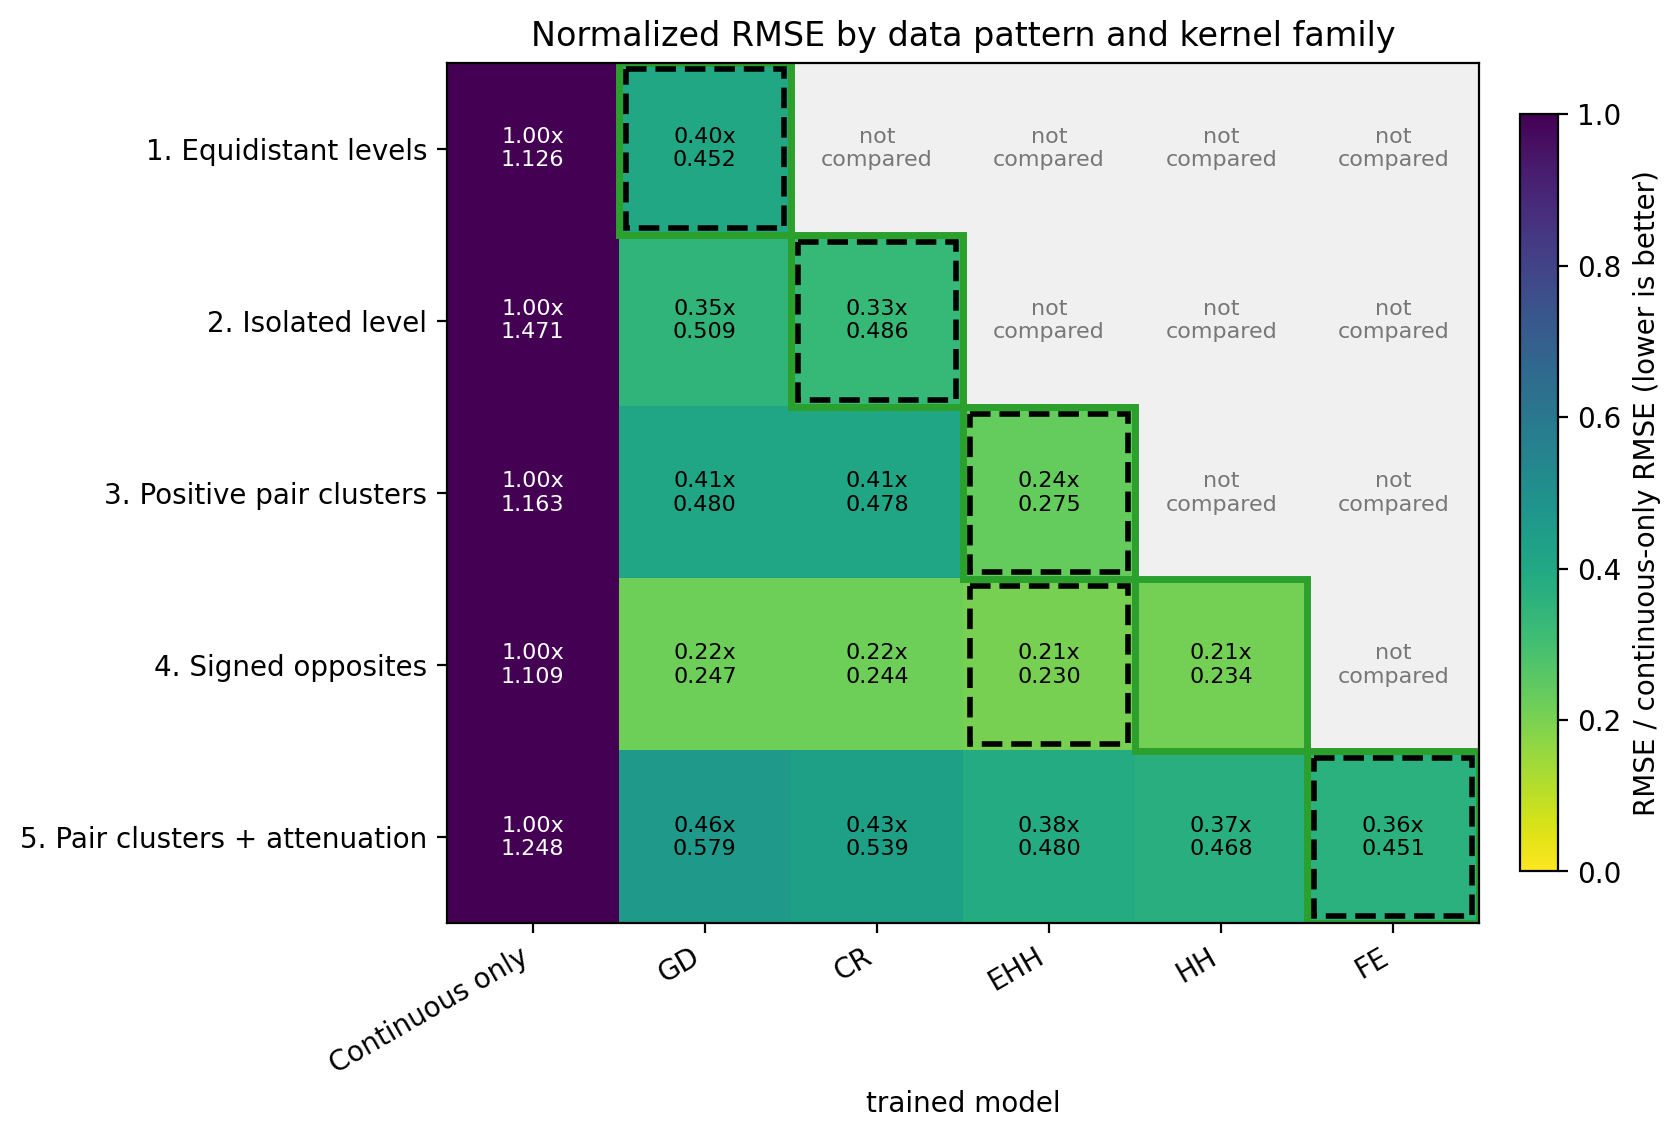

In [ ]:
from matplotlib.patches import Rectangle as _Rectangle

result_by_step_kernel = {
    (row["step"], row["kernel"]): row for row in progression_results
}
_rmse_matrix = []
_relative_matrix = []
_display_matrix = []
_best_indices = []
_target_indices = []
for _challenge in challenges:
    _row = [
        result_by_step_kernel[(_challenge["step"], _model_code)]["rmse"]
        for _model_code in model_codes
    ]
    _baseline = _row[model_codes.index("Continuous only")]
    _target_index = model_codes.index(_challenge["target_kernel"])
    _display_row = [
        _value / _baseline if _index <= _target_index else np.nan
        for _index, _value in enumerate(_row)
    ]
    _rmse_matrix.append(_row)
    _relative_matrix.append([_value / _baseline for _value in _row])
    _display_matrix.append(_display_row)
    _best_indices.append(
        min(range(_target_index + 1), key=lambda _index: _row[_index])
    )
    _target_indices.append(_target_index)

_fig, _ax = plt.subplots(figsize=(8.9, 5.8))
_cmap = plt.get_cmap("viridis_r").copy()
_cmap.set_bad("#f0f0f0")
_masked_display = np.ma.masked_invalid(np.array(_display_matrix, dtype=np.float32))
_im = _ax.imshow(_masked_display, cmap=_cmap, vmin=0.0, vmax=1.0)
_ax.set_xticks(range(len(model_codes)))
_ax.set_xticklabels(model_codes, rotation=30, ha="right")
_ax.set_yticks(range(len(challenges)))
_ax.set_yticklabels([_challenge["step"] for _challenge in challenges])
_ax.set_title("Normalized RMSE by data pattern and kernel family")
_ax.set_xlabel("trained model")
_ax.set_ylabel("")

for _row_index, _challenge in enumerate(challenges):
    _target_index = _target_indices[_row_index]
    for _col_index, _model_code in enumerate(model_codes):
        _relative = _relative_matrix[_row_index][_col_index]
        _rmse = _rmse_matrix[_row_index][_col_index]
        if _col_index > _target_index:
            _ax.text(
                _col_index,
                _row_index,
                "not\ncompared",
                ha="center",
                va="center",
                fontsize=8,
                color="#777777",
            )
            continue
        _rgba = _im.cmap(_im.norm(_relative))
        _luminance = 0.299 * _rgba[0] + 0.587 * _rgba[1] + 0.114 * _rgba[2]
        _text_color = "white" if _luminance < 0.45 else "black"
        _ax.text(
            _col_index,
            _row_index,
            f"{_relative:.2f}x\n{_rmse:.3f}",
            ha="center",
            va="center",
            fontsize=8,
            color=_text_color,
        )
    _best_index = _best_indices[_row_index]
    _ax.add_patch(
        _Rectangle(
            (_target_index - 0.5, _row_index - 0.5),
            1.0,
            1.0,
            fill=False,
            edgecolor="#2ca02c",
            linewidth=2.5,
        )
    )
    _ax.add_patch(
        _Rectangle(
            (_best_index - 0.46, _row_index - 0.46),
            0.92,
            0.92,
            fill=False,
            edgecolor="black",
            linewidth=2.0,
            linestyle="--",
        )
    )
_cbar = _fig.colorbar(_im, ax=_ax, shrink=0.88, pad=0.03)
_cbar.set_label("RMSE / continuous-only RMSE (lower is better)")
_fig.tight_layout()

mo.vstack(
    [
        mo.md(
            """
            ## Fitted Model Progression

            Each row fits all five categorical kernels plus the continuous
            baseline, but the heatmap is shown as a decision ladder. A row
            displays only the baseline and the kernel families introduced up
            to that step; later, more flexible families are blanked out rather
            than treated as automatic winners for simpler patterns.

            The numbers are `RMSE / continuous-only RMSE`, with the absolute
            RMSE underneath. Values below `1.00x` improve on the continuous
            baseline. The green outline marks the intended kernel family for
            that synthetic pattern; the black dashed outline marks the best
            displayed model in that row.
            """
        ),
        mo.mpl.interactive(_fig),
    ]
)

## Example Usage

```python
from mojogp import EHH, RBF, SingleOutputGP

# X has continuous columns 0 and 1, and one categorical column 2.
# Category values must be integer-coded from 0 to levels - 1.
kernel = RBF(active_dims=[0, 1]) * EHH(levels=5, active_dims=[2])

gp = SingleOutputGP(kernel)
gp.fit(X_train, y_train, method="materialized", progress=True)
mean, variance = gp.predict(X_test, return_variance=True)
```

## References

Saves, P., Diouane, Y., Bartoli, N., Lefebvre, T. and Morlier, J. (2023). A mixed-categorical correlation kernel for Gaussian process. Neurocomputing, [online] 550, p.126472. doi:https://doi.org/10.1016/j.neucom.2023.126472.

Perez, R.C., Veiga, D. and Garnier, J. (2025). A reproducible comparative study of categorical kernels for Gaussian process regression, with new clustering-based nested kernels. [online] arXiv.org. Available at: https://arxiv.org/abs/2510.01840 [Accessed 22 May 2026].

Roustant, O., Padonou, E., Deville, Y., Clément, A., Perrin, G., Giorla, J. and Wynn, H. (2018). Group kernels for Gaussian process metamodels with categorical inputs. [online] arXiv.org. Available at: https://arxiv.org/abs/1802.02368 [Accessed 22 May 2026].